In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_h5_clips(h5_path, num_clips=2):
    """
    Visualize raw clips from the H5 file showing the teacher (global) and student (local) views.
    
    Args:
        h5_path: Path to the H5 file
        num_clips: Number of clips to visualize
    """
    with h5py.File(h5_path, 'r') as f:
        total_clips = len(f.keys())
        print(f"Total number of clips in dataset: {total_clips}")
        
        # Visualize specified number of random clips
        clip_indices = np.random.choice(total_clips, num_clips, replace=False)
        
        for clip_idx in clip_indices:
            clip_group = f[str(clip_idx)]
            num_views = len(clip_group.keys())
            
            # Create a figure with subplots for each frame in the clip
            num_frames = clip_group['0'].shape[0]  # number of frames in teacher view
            fig, axes = plt.subplots(num_views, num_frames, 
                                   figsize=(3*num_frames, 3*num_views))
            fig.suptitle(f'Clip {clip_idx} - All Views and Frames')
            
            # Plot each view
            for view_idx in range(num_views):
                frames = torch.from_numpy(clip_group[str(view_idx)][()])
                
                # Plot each frame in the view
                for frame_idx in range(num_frames):
                    ax = axes[view_idx, frame_idx] if num_views > 1 else axes[frame_idx]
                    frame = frames[frame_idx].permute(1, 2, 0)
                    ax.imshow(frame.clip(0, 1))  # Clip values to [0,1] for visualization
                    ax.axis('off')

                    # Get frame dimensions
                    height, width, _ = frame.shape
                    ax.text(5, 15, f'{width}x{height}', color='white', fontsize=12,
                            bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))
                    
                    if frame_idx == 0:
                        ax.set_title(f'View {view_idx}\n{"Teacher" if view_idx == 0 else "Student"}')
            
            plt.tight_layout()
            plt.show()


Total number of clips in dataset: 20970


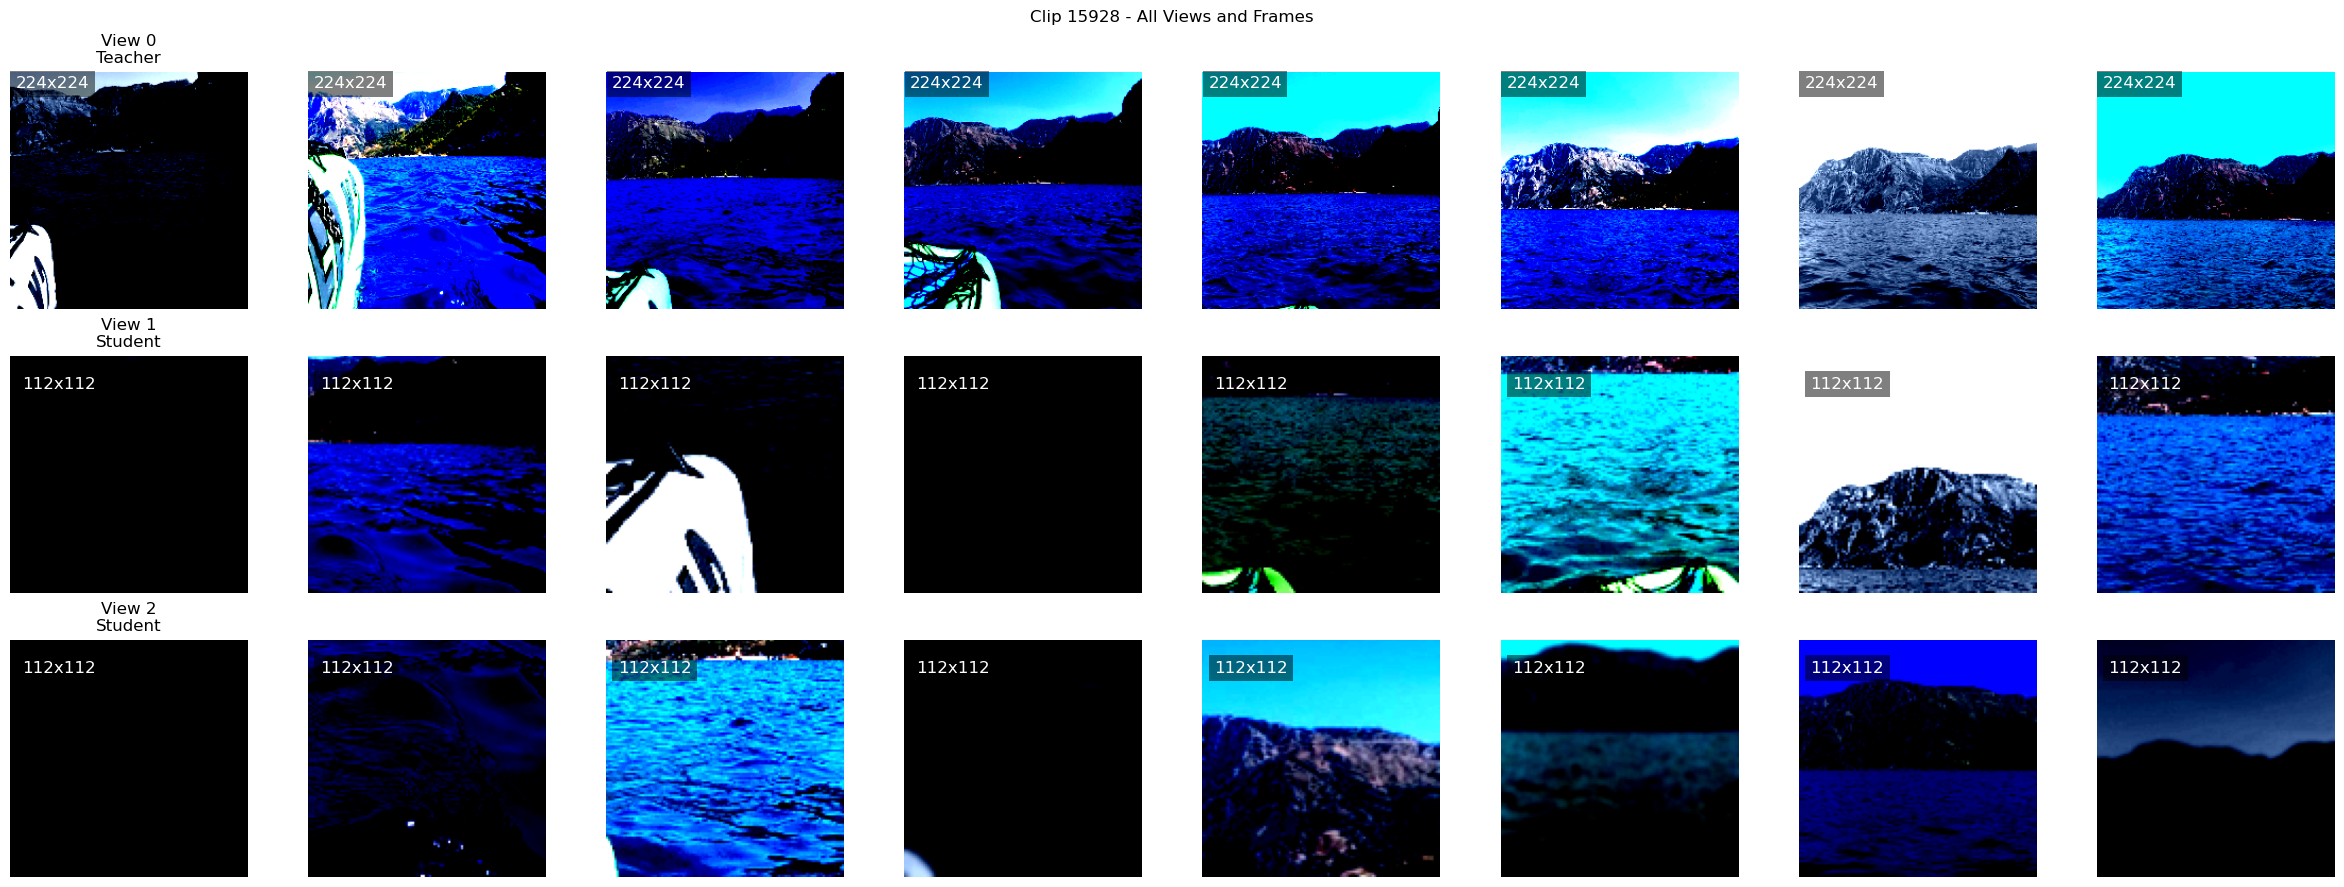

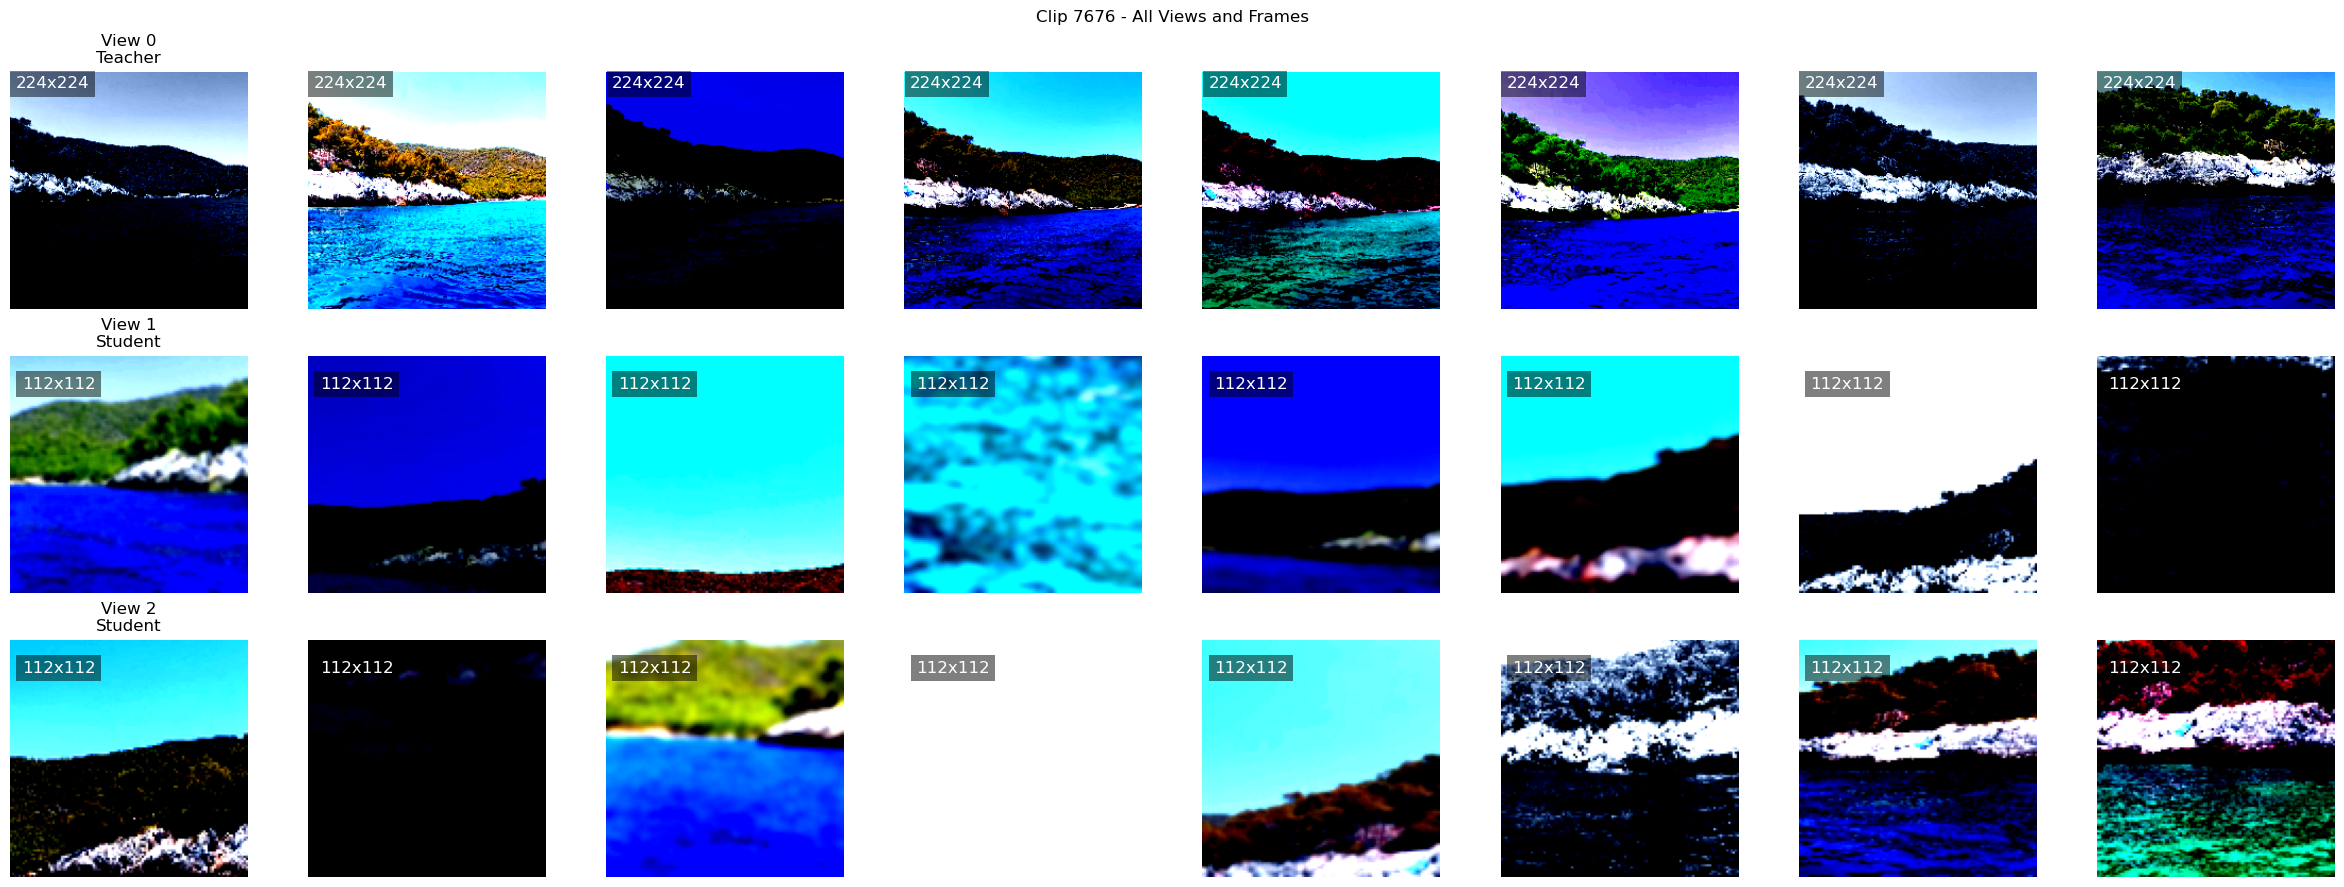

In [9]:
# "/media/giorgos/Win11/computer_vision_project/dataset.hdf5"

visualize_h5_clips("/home/giorgos/computer_vision/project/computer_vision_project/preprocessed_dataset/dataset.hdf5")

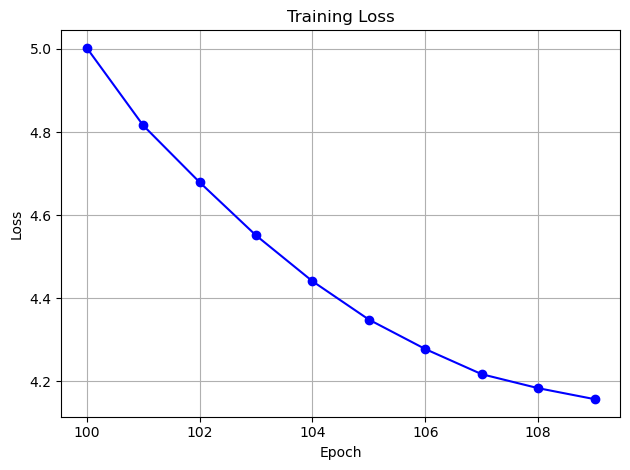

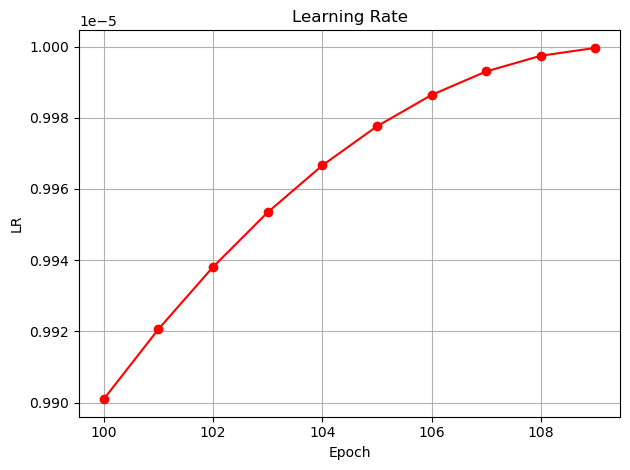

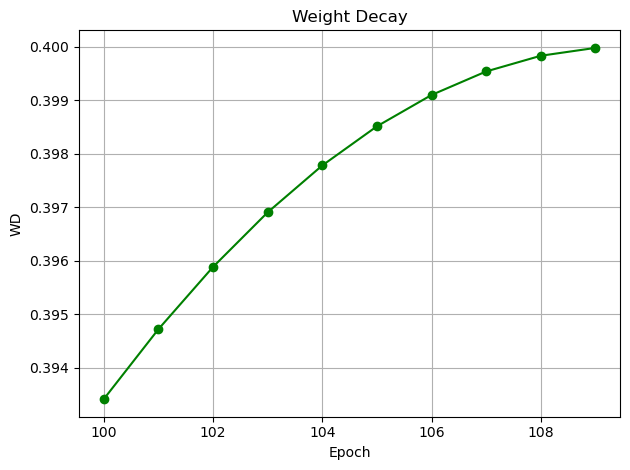

In [4]:
import json
import matplotlib.pyplot as plt

train_loss = []
train_lr = []
train_wd = []
epochs = []

with open('checkpoint/log.txt', 'r') as file:
    for line in file:
        data = json.loads(line.strip())
        train_loss.append(data['train_loss'])
        train_lr.append(data['train_lr'])
        train_wd.append(data['train_wd'])
        epochs.append(data['epoch'])


# Plot the training loss
plt.plot(epochs, train_loss, marker='o', color='b')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.tight_layout()
plt.show()
# Plot the learning rate
plt.plot(epochs, train_lr, marker='o', color='r')
plt.title('Learning Rate')
plt.xlabel('Epoch')
plt.ylabel('LR')
plt.grid(True)
plt.tight_layout()
plt.show()
# Plot the weight decay
plt.plot(epochs, train_wd, marker='o', color='g')
plt.title('Weight Decay')
plt.xlabel('Epoch')
plt.ylabel('WD')
plt.grid(True)

plt.tight_layout()
plt.show()